# Olist Freight Pricing — EDA & BI

**Notebook:** `01_eda_and_bi.ipynb` | **Episode 1** | Reference: Morettin Ch. 1

---

## 1. Setup

In [435]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [436]:
conn = sqlite3.connect('/Volumes/STORAGE/olist-freight-pricing-engine/data/raw/olist.sqlite')

## 2. Database Structure

In [437]:
tabelas = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
tabelas

,name
0,product_category_name_translation
1,sellers
2,customers
3,geolocation
4,order_items
5,order_payments
6,order_reviews
7,orders
8,products
9,leads_qualified


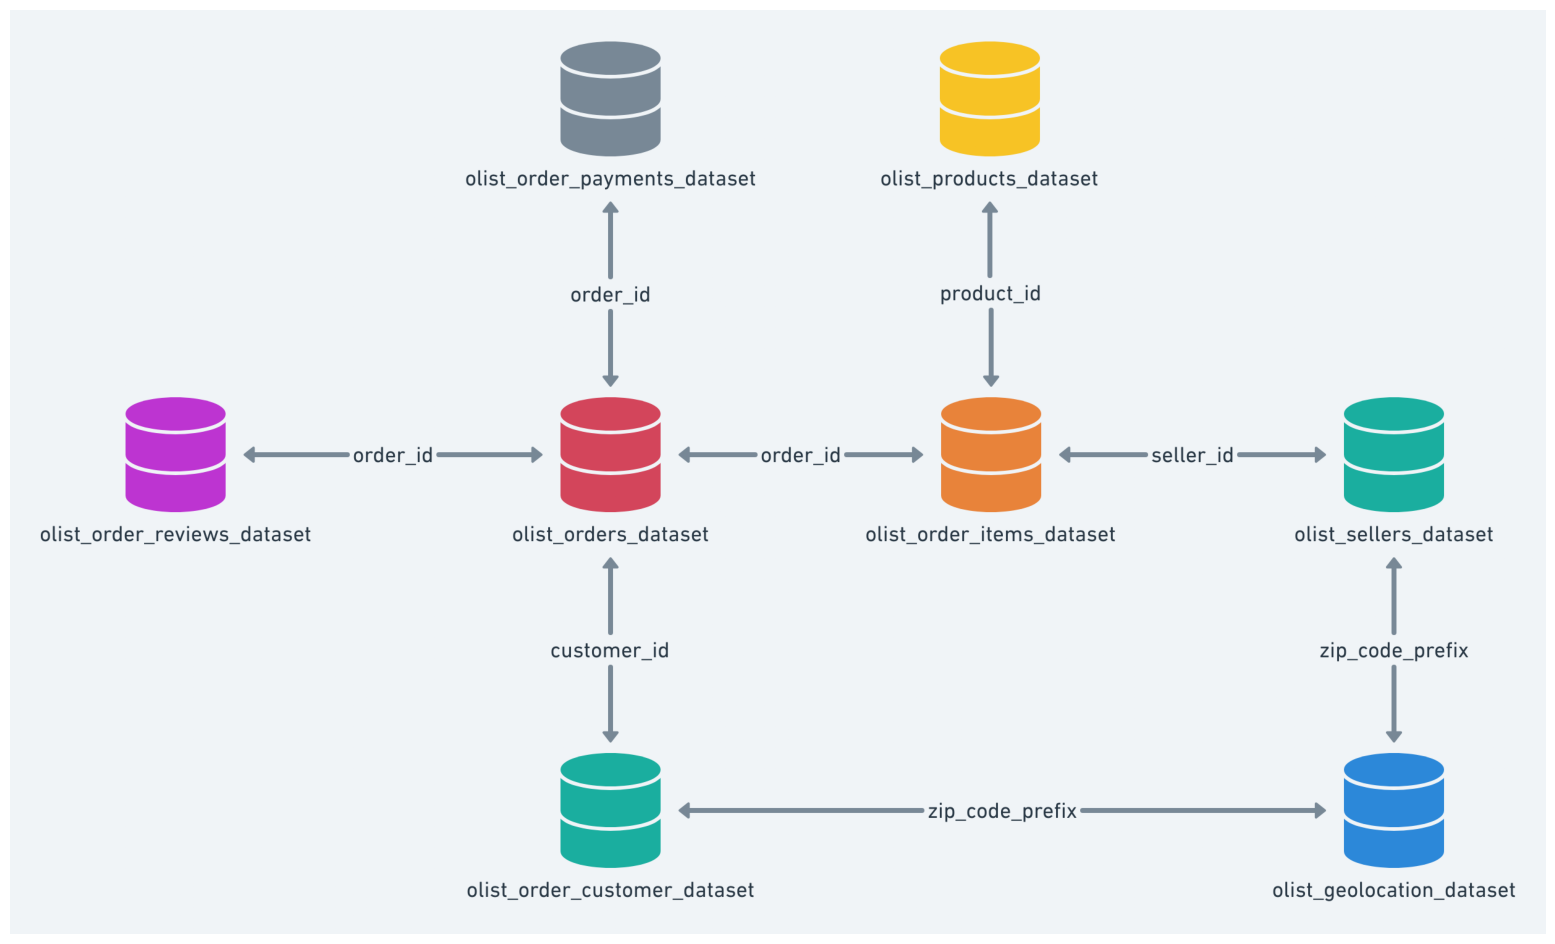

In [438]:
plt.figure(figsize=(20, 12))
img = mpimg.imread('/Volumes/STORAGE/olist-freight-pricing-engine/img/sql_structure_olist.png')
plt.imshow(img)
plt.axis('off')
plt.show()

## 3. Loading and Merge

Granularity: **order_item**. Central table: `orders`.

Pre-merge treatments:
- `order_payments`: aggregated by `order_id` (sum of value, max installments, most frequent payment type)
- `order_reviews`: only the most recent review per order is kept
- `geolocation`: deduplicated by `zip_code_prefix` and joined twice (seller and customer)

In [439]:
# load all tables
legenda        = pd.read_sql("SELECT * FROM product_category_name_translation", conn)
df_sellers     = pd.read_sql("SELECT * FROM sellers", conn)
df_customers   = pd.read_sql("SELECT * FROM customers", conn)
df_geolocation = pd.read_sql("SELECT * FROM geolocation", conn)
df_order_items = pd.read_sql("SELECT * FROM order_items", conn)
df_orders      = pd.read_sql("SELECT * FROM orders", conn)
df_products    = pd.read_sql("SELECT * FROM products", conn)
df_payments    = pd.read_sql("SELECT * FROM order_payments", conn)
df_reviews     = pd.read_sql("SELECT * FROM order_reviews", conn)

# geolocation: one record per zip code prefix (avoids row explosion on merge)
df_geo = df_geolocation.drop_duplicates(subset='geolocation_zip_code_prefix')

# payments: aggregate per order
df_payments_agg = (
    df_payments
    .groupby('order_id', as_index=False)
    .agg(
        payment_installments=('payment_installments', 'max'),
        payment_value=('payment_value', 'sum'),
        payment_type=('payment_type', lambda x: x.mode()[0])
    )
)

# reviews: keep most recent review per order
df_reviews_last = (
    df_reviews
    .sort_values('review_creation_date', ascending=False)
    .drop_duplicates(subset='order_id')
    [['order_id', 'review_score', 'review_creation_date']]
)

# main merge
df = (
    df_order_items
    .merge(df_orders,       on='order_id',   how='left')
    .merge(df_products,     on='product_id', how='left')
    .merge(legenda,         on='product_category_name', how='left')
    .merge(df_sellers,      on='seller_id',  how='left')
    .merge(df_customers,    on='customer_id', how='left')
    .merge(df_payments_agg, on='order_id',   how='left')
    .merge(df_reviews_last, on='order_id',   how='left')
    .merge(
        df_geo.rename(columns={
            'geolocation_zip_code_prefix': 'seller_zip_code_prefix',
            'geolocation_lat': 'seller_lat',
            'geolocation_lng': 'seller_lng',
            'geolocation_city': 'seller_city_geo',
            'geolocation_state': 'seller_state_geo'
        }),
        on='seller_zip_code_prefix', how='left'
    )
    .merge(
        df_geo.rename(columns={
            'geolocation_zip_code_prefix': 'customer_zip_code_prefix',
            'geolocation_lat': 'customer_lat',
            'geolocation_lng': 'customer_lng',
            'geolocation_city': 'customer_city_geo',
            'geolocation_state': 'customer_state_geo'
        }),
        on='customer_zip_code_prefix', how='left'
    )
)

print(f"Shape: {df.shape}")
df.head()

Shape: (112650, 43)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,review_score,review_creation_date,seller_lat,seller_lng,seller_city_geo,seller_state_geo,customer_lat,customer_lng,customer_city_geo,customer_state_geo
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,...,5.0,2017-09-21 00:00:00,-22.498183,-44.123614,volta redonda,RJ,-21.758076,-41.312633,campos dos goytacazes,RJ
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,...,4.0,2017-05-13 00:00:00,-23.566258,-46.518417,sao paulo,SP,-20.212393,-50.941471,santa fe do sul,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,...,5.0,2018-01-23 00:00:00,-22.264094,-46.158564,borda da mata,MG,-19.860439,-44.597972,pará de minas,MG
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,...,4.0,2018-08-15 00:00:00,-20.548228,-47.395897,franca,SP,-23.144923,-46.539830,atibaia,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,...,5.0,2017-03-02 00:00:00,-22.931427,-53.133759,loanda,PR,-23.249008,-46.824961,varzea paulista,SP


## 4. Data Quality

### Identified Issues

| Column | Nulls (%) | Issue | Impact |
|---|---|---|---|
| `order_delivered_customer_date` | 2.18% | Orders not yet delivered (cancelled or in transit) | Drop for delivery time analysis |
| `product_category_name` / `_english` | 1.42% | Products with no category registered | Impute as "unknown" or drop |
| `product_weight_g` / dimensions | 0.02% | **Critical** — missing weight/dimensions blocks freight calculation | Impute using category median |
| `review_score` | 0.84% | Orders with no customer review | Keep as null (absence is informative) |
| `customer_lat/lng` | 0.27% | Customer zip codes with no match in geolocation table | Cross-reference with external zip code source |
| `seller_lat/lng` | 0.22% | Seller zip codes with no match in geolocation table | Same as above |
| `order_approved_at` | 0.01% | Orders with no payment approval | Investigate if cancelled |

### Type Issues
- All date columns are stored as `object` — convert to `datetime`
- `product_name_lenght` and `product_description_lenght` have a typo from the original dataset (keep as-is for traceability)

In [440]:
nulls = df.isnull().sum()
nulls = nulls[nulls > 0].sort_values(ascending=False)
nulls_pct = (nulls / len(df) * 100).round(2)

pd.DataFrame({'count': nulls, 'pct': nulls_pct})

,count,pct
order_delivered_customer_date,2454,2.18
product_category_name_english,1627,1.44
product_category_name,1603,1.42
product_name_lenght,1603,1.42
product_description_lenght,1603,1.42
product_photos_qty,1603,1.42
order_delivered_carrier_date,1194,1.06
review_creation_date,942,0.84
review_score,942,0.84
customer_state_geo,302,0.27


In [441]:
rows, cols = df.shape
print(f"Shape: {rows} rows x {cols} columns")

Shape: 112650 rows x 43 columns


In [442]:
print(df.dtypes)

order_id                          object
order_item_id                      int64
product_id                        object
seller_id                         object
shipping_limit_date               object
price                            float64
freight_value                    float64
customer_id                       object
order_status                      object
order_purchase_timestamp          object
order_approved_at                 object
order_delivered_carrier_date      object
order_delivered_customer_date     object
order_estimated_delivery_date     object
product_category_name             object
product_name_lenght              float64
product_description_lenght       float64
product_photos_qty               float64
product_weight_g                 float64
product_length_cm                float64
product_height_cm                float64
product_width_cm                 float64
product_category_name_english     object
seller_zip_code_prefix             int64
seller_city     

## 5. Variable Classification

Variables classified according to classical statistical taxonomy (Morettin Ch. 1).

**Cleaning criteria applied:**
- Duplicated city/state columns: kept `_geo` versions (from `geolocation` table), which have wider geographic coverage
- `product_category_name` removed: only `product_category_name_english` is kept

In [443]:
variable_types = {
    'Qualitative': {
        'Nominal': [
            # identifiers
            'order_id', 'product_id', 'seller_id',
            'customer_id', 'customer_unique_id',
            # category (English only — Portuguese is a duplicate)
            'product_category_name_english',
            # location (geo versions kept — more reliable coverage)
            'seller_zip_code_prefix', 'seller_city_geo', 'seller_state_geo',
            'customer_zip_code_prefix', 'customer_city_geo', 'customer_state_geo',
            # payment
            'payment_type',
        ],
        'Ordinal': [
            'order_status',   # created → approved → shipped → delivered
            'review_score',   # 1–5 scale, unequal intervals
        ]
    },
    'Quantitative': {
        'Discrete': [
            'order_item_id', 'product_name_lenght',
            'product_description_lenght',  # character count
            'product_photos_qty', 'payment_installments',
        ],
        'Continuous': [
            'price', 'freight_value', 'payment_value',
            'product_weight_g', 'product_length_cm',
            'product_height_cm', 'product_width_cm',
            'seller_lat', 'seller_lng',
            'customer_lat', 'customer_lng',
        ]
    },
    'Temporal': [
        'shipping_limit_date', 'order_purchase_timestamp',
        'order_approved_at', 'order_delivered_carrier_date',
        'order_delivered_customer_date', 'order_estimated_delivery_date',
        'review_creation_date',
    ]
}
variable_types

{'Qualitative': {'Nominal': ['order_id',
   'product_id',
   'seller_id',
   'customer_id',
   'customer_unique_id',
   'product_category_name_english',
   'seller_zip_code_prefix',
   'seller_city_geo',
   'seller_state_geo',
   'customer_zip_code_prefix',
   'customer_city_geo',
   'customer_state_geo',
   'payment_type'],
  'Ordinal': ['order_status', 'review_score']},
 'Quantitative': {'Discrete': ['order_item_id',
   'product_name_lenght',
   'product_description_lenght',
   'product_photos_qty',
   'payment_installments'],
  'Continuous': ['price',
   'freight_value',
   'payment_value',
   'product_weight_g',
   'product_length_cm',
   'product_height_cm',
   'product_width_cm',
   'seller_lat',
   'seller_lng',
   'customer_lat',
   'customer_lng']},
 'Temporal': ['shipping_limit_date',
  'order_purchase_timestamp',
  'order_approved_at',
  'order_delivered_carrier_date',
  'order_delivered_customer_date',
  'order_estimated_delivery_date',
  'review_creation_date']}

In [444]:
variable_types

{'Qualitative': {'Nominal': ['order_id',
   'product_id',
   'seller_id',
   'customer_id',
   'customer_unique_id',
   'product_category_name_english',
   'seller_zip_code_prefix',
   'seller_city_geo',
   'seller_state_geo',
   'customer_zip_code_prefix',
   'customer_city_geo',
   'customer_state_geo',
   'payment_type'],
  'Ordinal': ['order_status', 'review_score']},
 'Quantitative': {'Discrete': ['order_item_id',
   'product_name_lenght',
   'product_description_lenght',
   'product_photos_qty',
   'payment_installments'],
  'Continuous': ['price',
   'freight_value',
   'payment_value',
   'product_weight_g',
   'product_length_cm',
   'product_height_cm',
   'product_width_cm',
   'seller_lat',
   'seller_lng',
   'customer_lat',
   'customer_lng']},
 'Temporal': ['shipping_limit_date',
  'order_purchase_timestamp',
  'order_approved_at',
  'order_delivered_carrier_date',
  'order_delivered_customer_date',
  'order_estimated_delivery_date',
  'review_creation_date']}

## 6. Data Dictionary

| Column | Statistical Type | Model Role | Description |
|---|---|---|---|
| `freight_value` | Continuous | **Target (Y)** | Freight value per item in BRL — what the model predicts |
| `price` | Continuous | Covariate | Product price; correlates with weight and declared value for insurance |
| `product_weight_g` | Continuous | Key covariate | Weight in grams — main driver of freight cost |
| `product_length_cm` | Continuous | Key covariate | Length; combined with height and width for cubic weight |
| `product_width_cm` | Continuous | Key covariate | Width of the product |
| `product_height_cm` | Continuous | Key covariate | Height of the product |
| `seller_lat` / `seller_lng` | Continuous | Geographic covariate | Seller coordinates; used to compute distance to customer |
| `customer_lat` / `customer_lng` | Continuous | Geographic covariate | Customer coordinates |
| `seller_state_geo` | Nominal | Covariate | Seller state; proxy for regional logistics cost |
| `customer_state_geo` | Nominal | Covariate | Customer state; proxy for regional logistics cost |
| `seller_city_geo` / `customer_city_geo` | Nominal | Geographic complement | Origin/destination city for route analysis |
| `product_category_name_english` | Nominal | Covariate | Product category; groups with similar weight/dimension profiles |
| `payment_value` | Continuous | Auxiliary feature | Total order value including freight |
| `payment_installments` | Discrete | Auxiliary feature | Number of installments; indicator of ticket size |
| `payment_type` | Nominal | Auxiliary feature | Payment method (credit card, bank slip, etc.) |
| `order_status` | Ordinal | Filter | Order status — undelivered orders must be handled before modelling |
| `review_score` | Ordinal | Auxiliary feature | Customer satisfaction 1–5; may correlate with delays |
| `order_item_id` | Discrete | Auxiliary feature | Item number within the order; multi-item orders may share freight |
| `product_photos_qty` | Discrete | Auxiliary feature | Number of product photos; proxy for listing quality |
| `product_name_lenght` | Discrete | Auxiliary feature | Name length in characters; proxy for listing detail |
| `product_description_lenght` | Discrete | Auxiliary feature | Description length in characters |
| `order_id` | Nominal | Identifier | Order key; no predictive value |
| `product_id` | Nominal | Identifier | Product key |
| `seller_id` | Nominal | Identifier | Seller key |
| `customer_id` | Nominal | Identifier | Customer key per order (unique per order, not per person) |
| `customer_unique_id` | Nominal | Identifier | Real customer key across multiple orders |
| `seller_zip_code_prefix` / `customer_zip_code_prefix` | Nominal | Geographic identifier | 5-digit zip code prefix; base for coordinate join |
| `shipping_limit_date` | Temporal | Auxiliary feature | Seller shipping deadline |
| `order_purchase_timestamp` | Temporal | Auxiliary feature | Purchase date/time; useful for seasonality |
| `order_approved_at` | Temporal | Auxiliary feature | Payment approval timestamp |
| `order_delivered_carrier_date` | Temporal | Auxiliary feature | Handoff to carrier |
| `order_delivered_customer_date` | Temporal | Auxiliary feature | Delivery to customer; base for actual delivery time |
| `order_estimated_delivery_date` | Temporal | Auxiliary feature | Estimated delivery deadline |
| `review_creation_date` | Temporal | Auxiliary feature | Review submission date |

## 7. Removing Duplicate Columns

Columns removed due to information redundancy:

| Removed column | Kept | Reason |
|---|---|---|
| `product_category_name` | `product_category_name_english` | Same category, different language |
| `seller_city` | `seller_city_geo` | `geolocation` source has wider coverage |
| `seller_state` | `seller_state_geo` | Same reason |
| `customer_city` | `customer_city_geo` | Same reason |
| `customer_state` | `customer_state_geo` | Same reason |

In [445]:
df.drop(columns=['product_category_name', 'seller_city', 'seller_state'], inplace=True)

In [446]:
date_cols = [
    'order_purchase_timestamp',
    'order_estimated_delivery_date',
    'order_delivered_customer_date',
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col])

df[date_cols].dtypes

order_purchase_timestamp         datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
order_delivered_customer_date    datetime64[ns]
dtype: object

## 8. Business Problem in Statistical Terms

> "Statistics is the science of learning from data." — Wasserman

### Formal Definitions

| Statistical Concept | Definition in the Olist Context |
|---|---|
| **Population** | All orders placed on the Olist platform in Brazil |
| **Sample** | 112,650 order_items with available data (period 2016–2018) |
| **Sampling unit** | One item within an order (`order_item_id`) |
| **Response variable (Y)** | `freight_value` — freight cost charged per item (BRL) |

### Model Structure

```
Y = freight_value

Physical covariates (X1):
  product_weight_g, product_length_cm, product_width_cm, product_height_cm

Geographic covariates (X2):
  seller_lat, seller_lng, customer_lat, customer_lng
  seller_state_geo, customer_state_geo

Business covariates (X3):
  product_category_name_english, price, payment_value, order_status
```

### Central Hypothesis

Freight is primarily determined by **weight**, **dimensions**, and **distance** between seller and customer.
`product_weight_g` and the geodesic seller–customer distance are expected to be the most important predictors in the final model.

## 9. Frequency Tables

### 9.1 Sellers by State

In [447]:
df_freq_sellers = (
    df['seller_state_geo']
    .value_counts(ascending=True)
    .reset_index()
    .rename(columns={'seller_state_geo': 'state', 'count': 'count'})
)

In [448]:
df_freq_sellers['cumulative'] = df_freq_sellers['count'].cumsum()

In [449]:
total_sellers = df_freq_sellers['cumulative'].iloc[-1]

In [450]:
df_freq_sellers['pct'] = (df_freq_sellers['cumulative'] / total_sellers * 100).round(2)

In [451]:
df_freq_sellers[df_freq_sellers['pct'] >= 10]

,state,count,cumulative,pct
18,RJ,4977,15107,13.44
19,PR,8778,23885,21.25
20,MG,8945,32830,29.21
21,SP,79567,112397,100.00


### 9.2 Customers by State

In [452]:
df_freq_customers = (
    df['customer_state_geo']
    .value_counts(ascending=True)
    .reset_index()
    .rename(columns={'customer_state_geo': 'state', 'count': 'count'})
)

In [453]:
df_freq_customers['cumulative'] = df_freq_customers['count'].cumsum()

In [454]:
total_customers = df_freq_customers['cumulative'].iloc[-1]

In [455]:
df_freq_customers['pct'] = (df_freq_customers['cumulative'] / total_customers * 100).round(2)

In [456]:
df_freq_sellers

,state,count,cumulative,pct
0,AC,1,1,0.00
1,AM,3,4,0.00
2,SE,10,14,0.01
3,PI,12,26,0.02
4,RO,14,40,0.04
5,PB,38,78,0.07
6,MS,50,128,0.11
7,RN,54,182,0.16
8,CE,94,276,0.25
9,MT,145,421,0.37


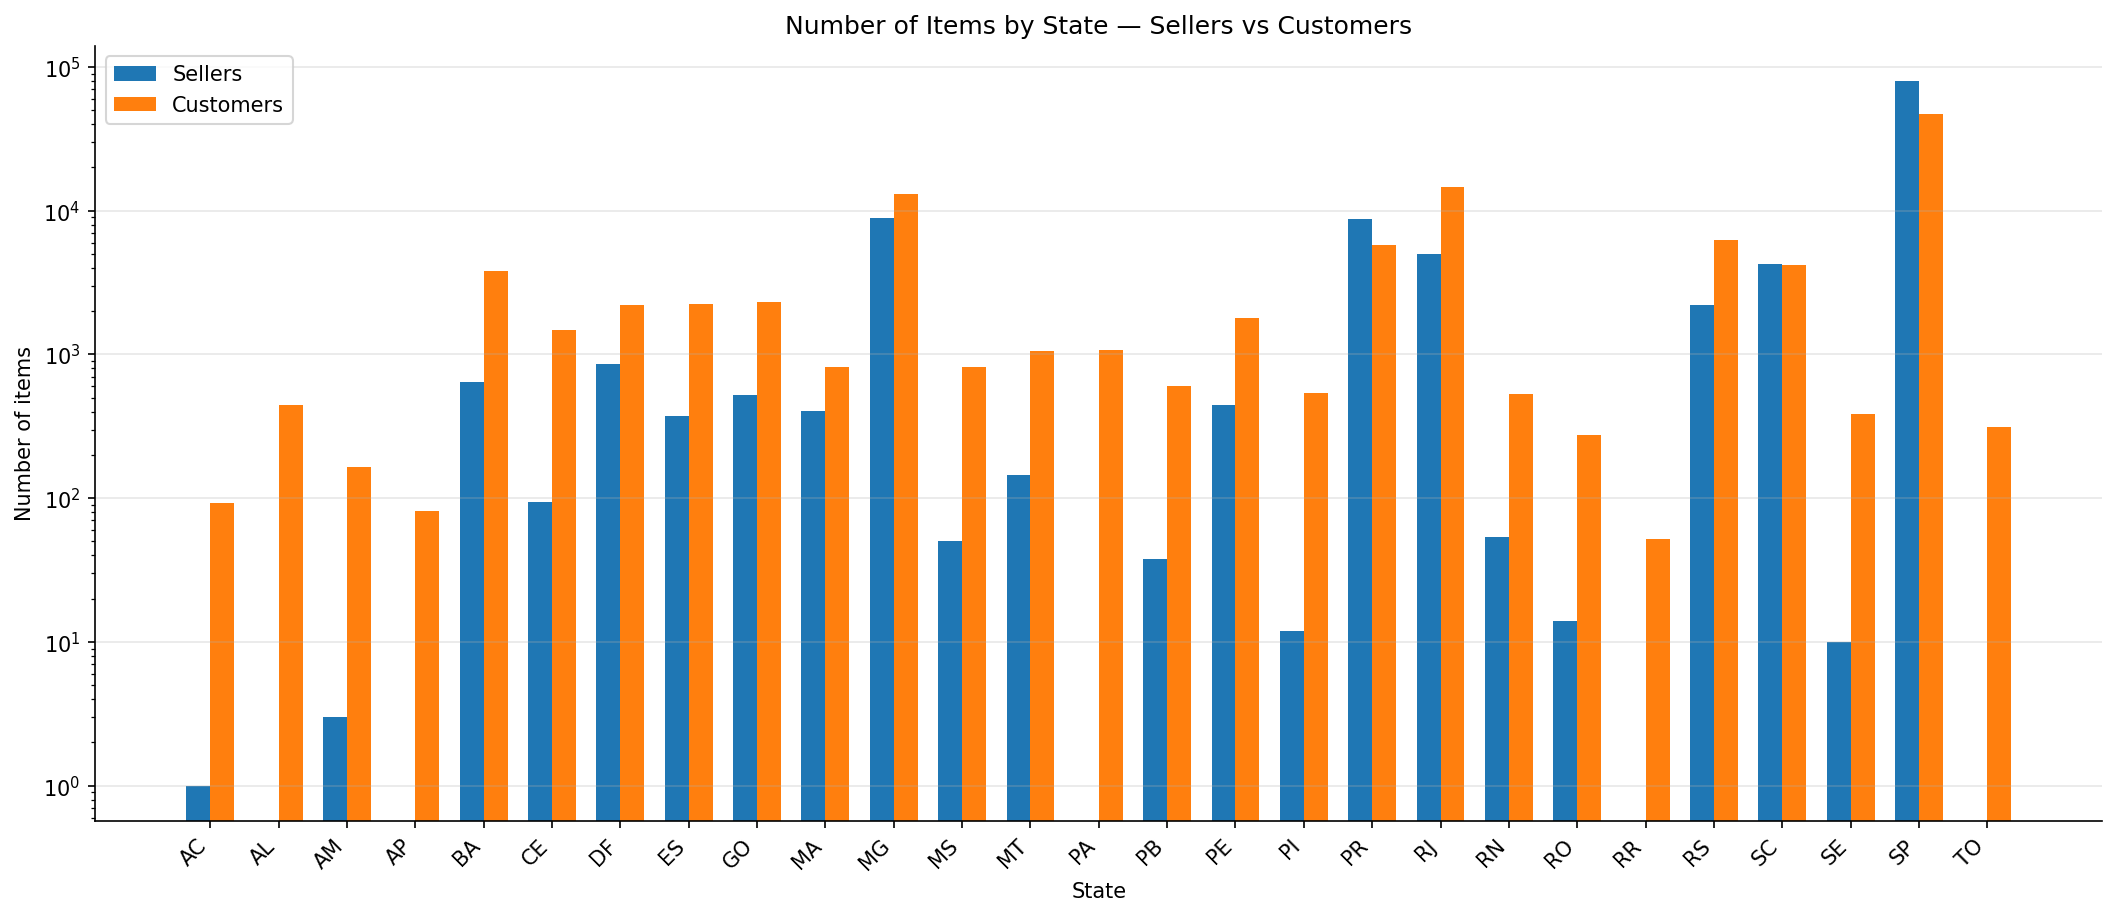

In [457]:
all_states = sorted(
    set(df['seller_state_geo'].dropna()) | set(df['customer_state_geo'].dropna())
)

sellers_by_state  = df.groupby('seller_state_geo')['order_id'].count().reindex(all_states, fill_value=0)
customers_by_state = df.groupby('customer_state_geo')['order_id'].count().reindex(all_states, fill_value=0)

counts = {'Sellers': sellers_by_state.values, 'Customers': customers_by_state.values}

x = np.arange(len(all_states))
width = 0.35
multiplier = 0

fig, ax = plt.subplots(figsize=(14, 6), dpi=150, layout='constrained')

for label, values in counts.items():
    ax.bar(x + width * multiplier, values, width, label=label)
    multiplier += 1

ax.set_xticks(x + width / 2)
ax.set_xticklabels(all_states, rotation=45, ha='right')
ax.set_ylabel('Number of items')
ax.set_xlabel('State')
ax.set_title('Number of Items by State — Sellers vs Customers')
ax.set_yscale('log')
ax.legend()
ax.grid(alpha=0.3, axis='y')
ax.spines[['top', 'right']].set_visible(False)

plt.show()

> **Observation:** Most sellers are concentrated in Sao Paulo (SP), while customers are more evenly distributed across states.

## 10. Price & Freight Analysis

In [458]:
df['price'].describe().round(2)

count    112650.00
mean        120.65
std         183.63
min           0.85
25%          39.90
50%          74.99
75%         134.90
max        6735.00
Name: price, dtype: float64

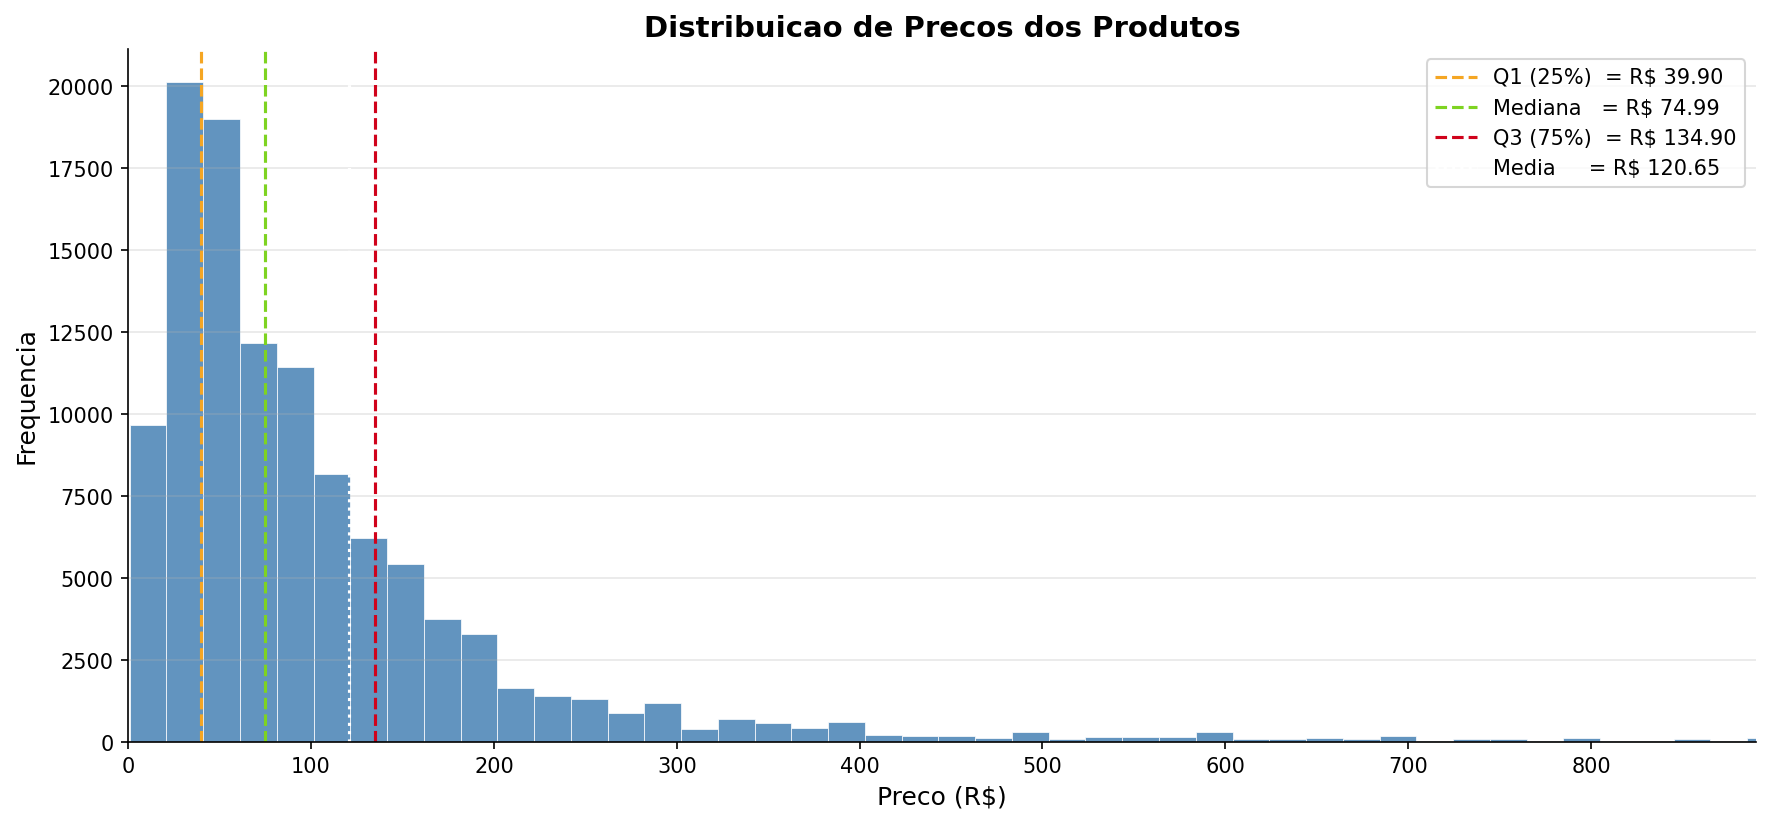

In [459]:
q25, median, q75 = df['price'].quantile([0.25, 0.50, 0.75])
mean = df['price'].mean()

fig, ax = plt.subplots(figsize=(14, 6), dpi=150)

ax.hist(df['price'], bins=int(len(df) ** 0.5),
        color='steelblue', edgecolor='white', linewidth=0.4, alpha=0.85)

ax.axvline(q25,    color='#f5a623', linestyle='--', linewidth=1.5, label=f'Q1 (25%)  = R$ {q25:.2f}')
ax.axvline(median, color='#7ed321', linestyle='--', linewidth=1.5, label=f'Mediana   = R$ {median:.2f}')
ax.axvline(q75,    color='#d0021b', linestyle='--', linewidth=1.5, label=f'Q3 (75%)  = R$ {q75:.2f}')
ax.axvline(mean,   color='white',   linestyle=':',  linewidth=1.5, label=f'Media     = R$ {mean:.2f}')

ax.set_xlabel('Preco (R$)', fontsize=12)
ax.set_ylabel('Frequencia', fontsize=12)
ax.set_title('Distribuicao de Precos dos Produtos', fontsize=14, fontweight='bold')
ax.set_xlim(0, df['price'].quantile(0.99))
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.show()


In [460]:
df_review_scores = (
    df['review_score']
    .value_counts()
    .reset_index()
    .sort_values('review_score')
)

In [461]:
df_review_scores

,review_score,count
2,1.0,14137
4,2.0,3843
3,3.0,9375
1,4.0,21203
0,5.0,63150


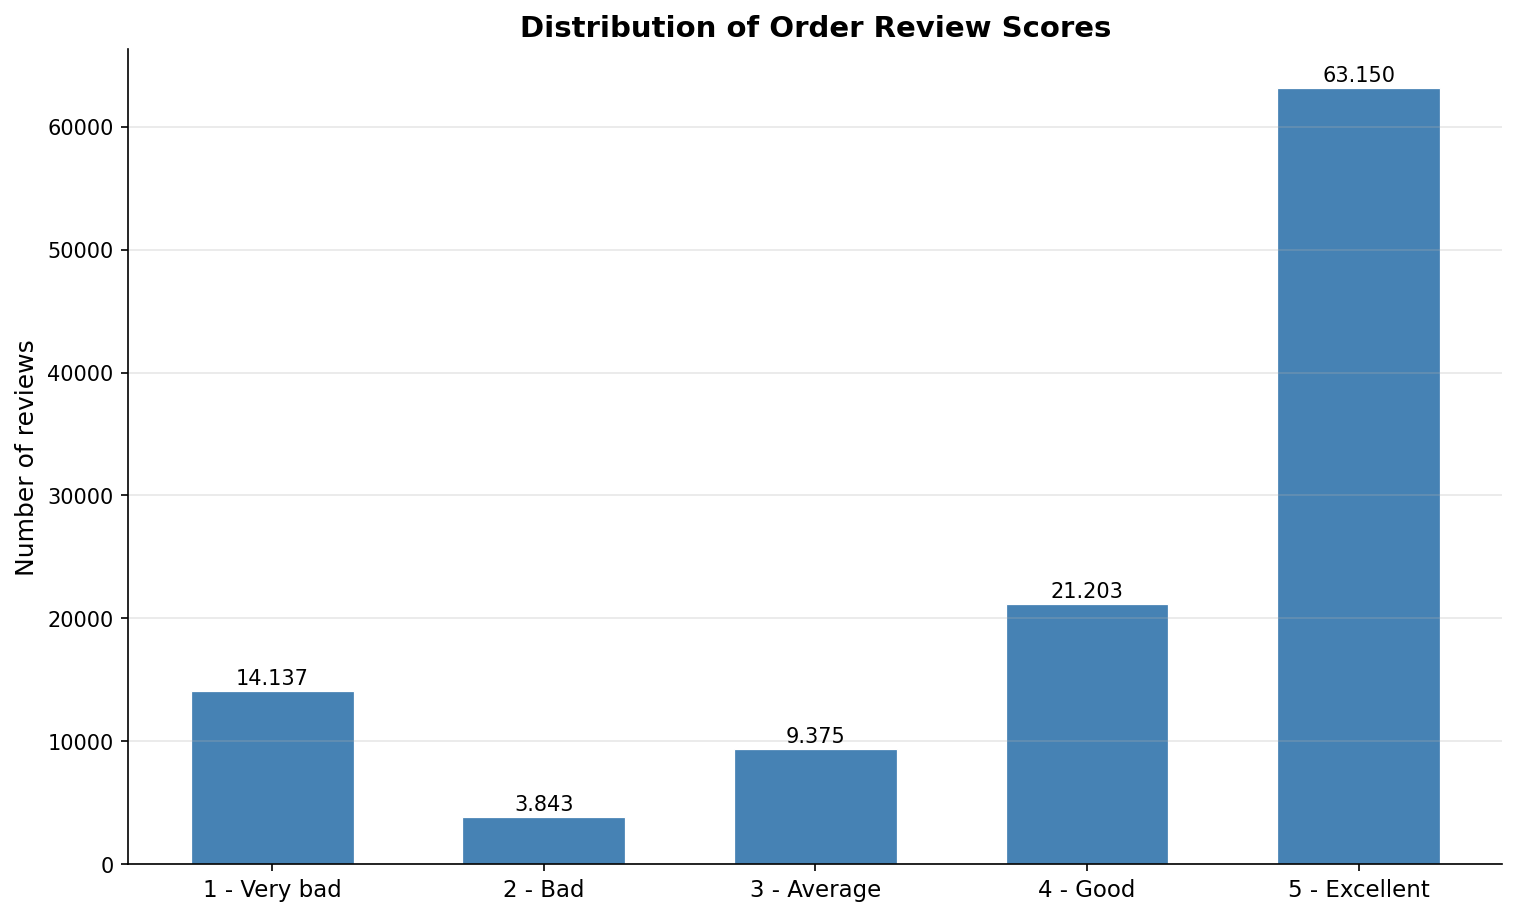

In [462]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=150, layout='constrained')

bars = ax.bar(
    df_review_scores['review_score'].astype(int),
    df_review_scores['count'],
    color='steelblue',
    edgecolor='white',
    linewidth=0.6,
    width=0.6,
)

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 200,
        f'{int(bar.get_height()):,}'.replace(',', '.'),
        ha='center', va='bottom', fontsize=10
    )

ax.set_xticks([1, 2, 3, 4, 5])
ax.set_xticklabels(['1 - Very bad', '2 - Bad', '3 - Average', '4 - Good', '5 - Excellent'], fontsize=11)
ax.set_ylabel('Number of reviews', fontsize=12)
ax.set_title('Distribution of Order Review Scores', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.show()

In [463]:
df_state_prices = df[['seller_state_geo', 'price']]

In [464]:
df_state_prices.groupby('seller_state_geo')['price'].agg(
    total='sum',
    mean='mean',
    q25=lambda x: x.quantile(0.25),
    q75=lambda x: x.quantile(0.75),
).round(2)

,total,mean,q25,q75
seller_state_geo,,,,
AC,267.00,267.00,267.00,267.00
AM,1177.00,392.33,114.00,531.50
BA,286903.56,443.44,170.00,599.00
CE,20240.64,215.33,48.00,399.00
DF,89881.68,104.76,35.17,120.00
ES,47779.51,128.10,89.00,112.00
GO,66399.21,127.69,49.90,158.90
MA,36408.95,89.90,64.99,122.99
MG,1031107.18,115.27,39.99,136.90


/var/folders/rq/f82lhxqs1p3dtw5q_8fm4hxh0000gn/T/ipykernel_4799/3654257822.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


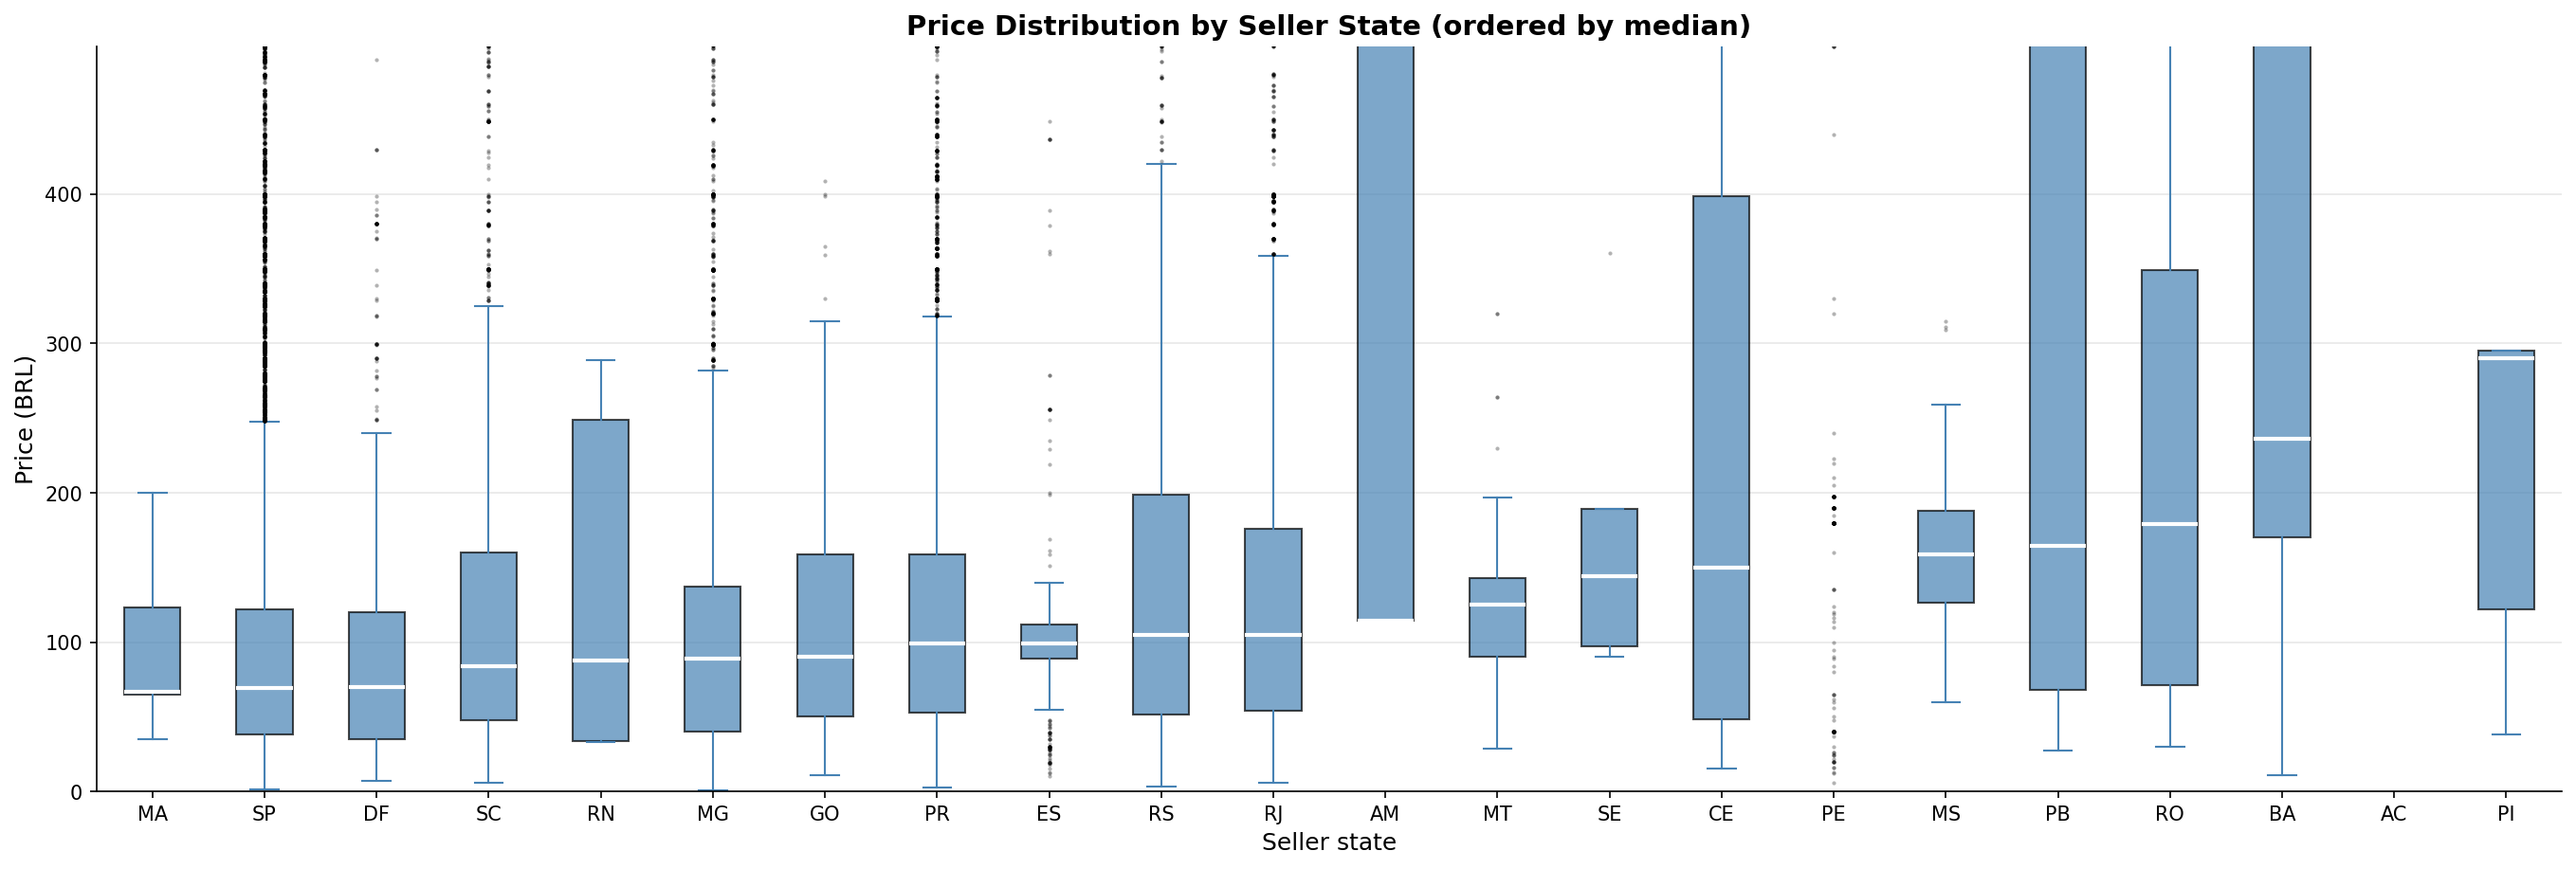

In [465]:
states_ordered = (
    df.groupby('seller_state_geo')['price'].median()
    .sort_values()
    .index.tolist()
)

data_by_state = [
    df.loc[df['seller_state_geo'] == s, 'price'].dropna().values
    for s in states_ordered
]

fig, ax = plt.subplots(figsize=(18, 6), dpi=150, layout='constrained')

ax.boxplot(
    data_by_state,
    labels=states_ordered,
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.7),
    medianprops=dict(color='white', linewidth=2),
    flierprops=dict(marker='.', markersize=2, alpha=0.3, color='steelblue'),
    whiskerprops=dict(color='steelblue'),
    capprops=dict(color='steelblue'),
)

ax.set_ylim(0, df['price'].quantile(0.97))
ax.set_xlabel('Seller state', fontsize=12)
ax.set_ylabel('Price (BRL)', fontsize=12)
ax.set_title('Price Distribution by Seller State (ordered by median)', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.show()

## 11. Estimated Delivery Deadline

Delivery deadline = `order_estimated_delivery_date` - `order_purchase_timestamp` (in days).

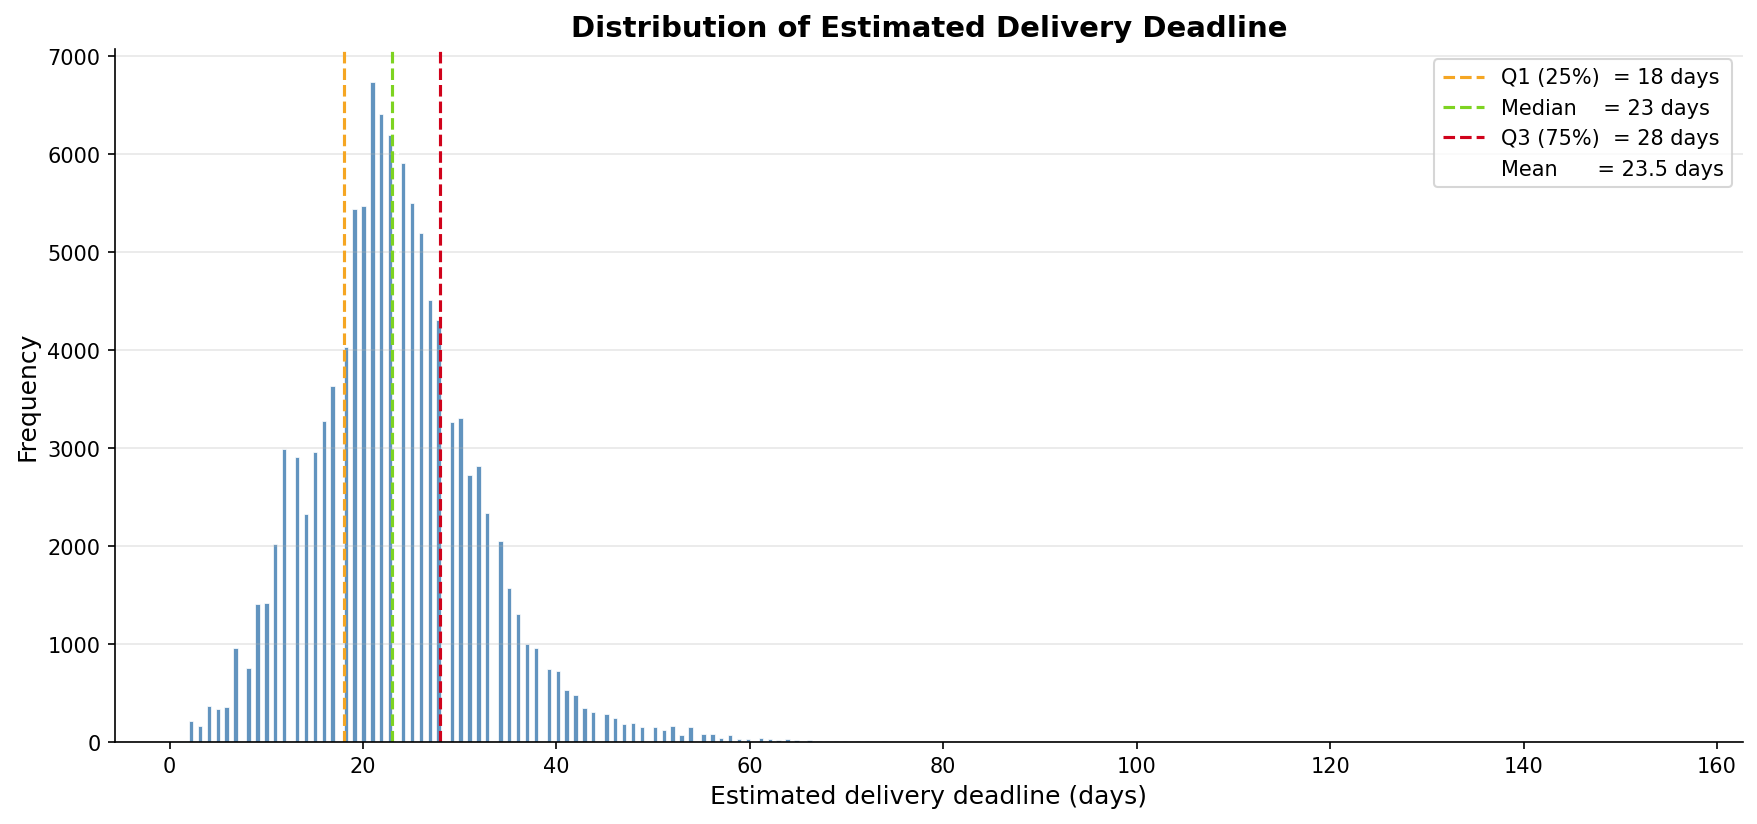

count    112650.0
mean         23.5
std           8.9
min           2.0
25%          18.0
50%          23.0
75%          28.0
max         155.0
Name: estimated_delivery_days, dtype: float64

In [466]:
df['estimated_delivery_days'] = (
    df['order_estimated_delivery_date'] - df['order_purchase_timestamp']
).dt.days

q25, median, q75 = df['estimated_delivery_days'].quantile([0.25, 0.50, 0.75])
mean = df['estimated_delivery_days'].mean()

fig, ax = plt.subplots(figsize=(14, 6), dpi=150)

ax.hist(df['estimated_delivery_days'].dropna(), bins=int(len(df) ** 0.5),
        color='steelblue', edgecolor='white', linewidth=0.4, alpha=0.85)

ax.axvline(q25,    color='#f5a623', linestyle='--', linewidth=1.5, label=f'Q1 (25%)  = {q25:.0f} days')
ax.axvline(median, color='#7ed321', linestyle='--', linewidth=1.5, label=f'Median    = {median:.0f} days')
ax.axvline(q75,    color='#d0021b', linestyle='--', linewidth=1.5, label=f'Q3 (75%)  = {q75:.0f} days')
ax.axvline(mean,   color='white',   linestyle=':',  linewidth=1.5, label=f'Mean      = {mean:.1f} days')

ax.set_xlabel('Estimated delivery deadline (days)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Estimated Delivery Deadline', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.show()

df['estimated_delivery_days'].describe().round(1)

In [468]:
df.to_parquet(
    '/Volumes/STORAGE/olist-freight-pricing-engine/data/processed/olist_merged.parquet',
    index=False
)
print(f'Saved: {df.shape[0]:,} rows x {df.shape[1]} columns')

Saved: 112,650 rows x 41 columns
